<div style="display:flex; align-items:center; gap:18px; text-align:left">
<img src="https://sebastiancontz.github.io/ust-introduccion-machine-learning/assets/logo-ust.svg" width="100" alt="Logo de la Universidad Santo Tomás">
<div>
<p>Ingeniería en Información y Control de Gestión</p>
<p>Facultad de Economía y Negocios</p>
<p>Introducción a Machine Learning</p>
<p>Semana 03: Análisis exploratorio y calidad de datos</p>
</div>
</div>

# 03 · Análisis exploratorio y calidad de datos

Una cartera de **612 facturas** de una empresa de servicios. El archivo declara **cero celdas
vacías**, y aun así no está limpio.

Hoy no se corrige nada. Se **detecta** y se **documenta**. Lo que sale de este notebook es una
**bitácora de hallazgos**, que es el insumo de la clase 4.

> Los datos son **sintéticos**, creados para el curso. El caso es real en su estructura, pero las
> cifras no sirven como referencia de mercado.

## La rutina

Los siete conceptos de la clase, convertidos en un procedimiento de cinco pasos. Este notebook es
esa rutina, en ese orden.

<p align="center"><img src="" width="980" alt="Rutina de auditoría en cinco pasos numerados. Paso uno, qué es cada columna: tipos y cuáles no son predictoras, con info y dtypes, y caza un número que llegó como texto. Paso dos, cómo se comporta cada una: cuántos datos hay y su centro, dispersión y forma, con describe y el histograma, y caza un promedio que esconde la forma. Paso tres, cómo se relacionan entre sí, de a dos y todas a la vez, con corr y groupby, y caza dos columnas que dicen lo mismo. Paso cuatro, qué se contradice: lo que debería cumplirse siempre, con duplicated y nunique, y caza un RUT con dos razones sociales. Paso cinco, de qué momento es cada dato y si se conoce antes de decidir, con crosstab y desviación estándar, y caza una cifra que solo existe después. Al pie, el resultado es una bitácora de hallazgos y no un archivo corregido"></p>

El orden no es arbitrario: no se puede describir una columna sin saber **qué tipo** es, ni buscar
contradicciones entre columnas sin conocer **cada una** por separado.

## Preparación del entorno

En Colab estas librerías ya vienen instaladas, así que la celda siguiente termina en segundos. Está
igual porque el notebook también tiene que ejecutarse fuera de Colab, y porque dejar escrito de qué
depende un análisis es parte de que sea reproducible.

In [1]:
%%capture
!pip install -q pandas matplotlib

## Cargar datos

Se lee **sin indicarle nada a pandas** sobre los tipos. Eso es a propósito: parte de lo que hay que
auditar es qué decidió pandas por su cuenta.

`isna` marca con True las celdas vacías, así que sumarlas cuenta cuántas hay.

In [2]:
import os
import pandas as pd

REPO = 'https://raw.githubusercontent.com/sebastiancontz/ust-introduccion-machine-learning-colab/main/ediciones/2026/datasets/'
BASE = '../datasets/' if os.path.exists('../datasets') else REPO

facturas = pd.read_csv(BASE + 'cobranza_servicios.csv')

facturas.info()

print()
print('Celdas vacías:', facturas.isna().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id_factura              612 non-null    str  
 1   rut_cliente             612 non-null    str  
 2   razon_social            612 non-null    str  
 3   segmento                612 non-null    str  
 4   region                  612 non-null    str  
 5   ejecutivo               612 non-null    str  
 6   prioridad_cobranza      612 non-null    str  
 7   fecha_emision           612 non-null    str  
 8   fecha_vencimiento       612 non-null    str  
 9   fecha_pago              612 non-null    str  
 10  dias_credito            612 non-null    int64
 11  monto_neto              612 non-null    int64
 12  monto_total             612 non-null    int64
 13  tasa_morosidad_cartera  612 non-null    str  
 14  estado_cobranza         612 non-null    str  
 15  monto_gestion_cobranza  612 non-nu

## La bitácora

Un hallazgo sin evidencia no es un hallazgo. «La columna de montos tiene problemas» no dice cuál, no
lo demuestra y no dice a quién le importa.

Cada hallazgo se registra con seis campos. La función de abajo los pide todos. Van a ver **tres
líneas escritas** a lo largo del cuaderno, y van a escribir **otras tres**: una en el paso 4, una en
el paso 5 y una a elección al final.

In [3]:
BITACORA = []

def anotar(variable, categoria, descripcion, evidencia, severidad, impacto):
    """Agrega una línea a la bitácora y la devuelve para revisarla.

    categoria : 'formato' | 'cantidad' | 'distribución' | 'momento'
    severidad : 'alta' | 'media' | 'baja'
    evidencia : la salida concreta que lo demuestra, no una impresión
    impacto   : a qué decisión afecta. Si no afecta a ninguna, revisar si es un hallazgo.
    """
    BITACORA.append({'variable': variable, 'categoría': categoria, 'descripción': descripcion,
                     'evidencia': evidencia, 'severidad': severidad, 'impacto': impacto})
    return pd.DataFrame(BITACORA[-1:])

---

# Parte 1 · Miren esto conmigo

Los pasos 1 y 2 de la rutina, con el ciclo completo: pregunta, mirada, hallazgo, línea de bitácora.

## Paso 1 · ¿Qué es cada columna?

Antes de calcular nada hay que saber con qué se está tratando. Diecisiete columnas.

> **Antes de ejecutar:** el archivo tiene columnas de identificación, de texto, de fecha y de
> número. ¿Cuántas creen que pandas leyó como **número**?

Según la versión de pandas, las columnas de texto aparecen como `object` o como `str`. Significan lo
mismo: **no es un número**.

In [4]:
facturas.dtypes

id_factura                  str
rut_cliente                 str
razon_social                str
segmento                    str
region                      str
ejecutivo                   str
prioridad_cobranza          str
fecha_emision               str
fecha_vencimiento           str
fecha_pago                  str
dias_credito              int64
monto_neto                int64
monto_total               int64
tasa_morosidad_cartera      str
estado_cobranza             str
monto_gestion_cobranza    int64
dias_atraso               int64
dtype: object

Ahora la misma pregunta, pero contada por `describe()`, que es lo que casi todo el mundo ejecuta
primero.

In [5]:
facturas.describe()

,dias_credito,monto_neto,monto_total,monto_gestion_cobranza,dias_atraso
count,612.000000,6.120000e+02,6.120000e+02,612.000000,612.000000
mean,44.950980,1.014250e+06,1.206958e+06,10876.568627,10.075163
std,20.560817,5.988906e+06,7.126798e+06,13817.735916,9.827692
min,30.000000,1.560000e+02,1.860000e+02,0.000000,0.000000
25%,30.000000,3.602500e+05,4.286975e+05,0.000000,0.000000
50%,30.000000,6.160000e+05,7.330400e+05,7450.000000,10.000000
75%,60.000000,9.882500e+05,1.176018e+06,15910.000000,16.000000
max,90.000000,1.480000e+08,1.761200e+08,117440.000000,49.000000


> **Cuenten las columnas de la salida anterior.** Después miren esta lista de nombres y digan cuál
> de todas ellas *debería* estar ahí y no está.

In [6]:
# las que pandas trata como números
numericas = facturas.select_dtypes(include='number').columns.tolist()

# las que NO, aunque su nombre suene a número
resto = [c for c in facturas.columns if c not in numericas]

print('pandas las trata como número :', numericas)
print()
print('el resto                     :', resto)

pandas las trata como número : ['dias_credito', 'monto_neto', 'monto_total', 'monto_gestion_cobranza', 'dias_atraso']

el resto                     : ['id_factura', 'rut_cliente', 'razon_social', 'segmento', 'region', 'ejecutivo', 'prioridad_cobranza', 'fecha_emision', 'fecha_vencimiento', 'fecha_pago', 'tasa_morosidad_cartera', 'estado_cobranza']


`tasa_morosidad_cartera` está en la segunda lista. Es un porcentaje, debería ser un número, y
`describe()` **no la mostró y no avisó**.

In [7]:
facturas['tasa_morosidad_cartera'].head(8)

0    5,7
1    3,1
2    3,9
3    2,7
4    6,1
5    6,2
6    6,2
7    5,5
Name: tasa_morosidad_cartera, dtype: str

Llegó con **coma decimal**: `5,7` en vez de `5.7`. Para pandas eso es texto, y a partir de ahí la
columna deja de existir para cualquier cálculo.

Este es el hallazgo más incómodo de la clase: `isna()` devuelve cero, `describe()` no reclama, y aun
así falta una columna entera del análisis. Lo único que lo detecta es **mirar el tipo**.

In [8]:
anotar(
    variable='tasa_morosidad_cartera',
    categoria='formato',
    descripcion='Llega con coma decimal y pandas la lee como texto, no como número.',
    evidencia=f"describe() devuelve {len(numericas)} columnas; select_dtypes('number') la excluye; "
              f"head() muestra '{facturas['tasa_morosidad_cartera'].iloc[0]}'",
    severidad='alta',
    impacto='Queda fuera de todo cálculo sin que nada avise. Cualquier análisis que la involucre '
            'está incompleto y parece completo.',
)

,variable,categoría,descripción,evidencia,severidad,impacto
0,tasa_morosidad_cartera,formato,Llega con coma decimal y pandas la lee como te...,describe() devuelve 5 columnas; select_dtypes(...,alta,Queda fuera de todo cálculo sin que nada avise...


## Paso 2 · ¿Cómo se comporta cada una?

Ya sabemos qué es cada columna. Ahora, una por una: centro, dispersión y forma.

> **Antes de ejecutar:** el monto promedio de una factura de esta cartera, ¿está más cerca del
> promedio o de la mediana? ¿Y cuánto creen que se diferencian?

In [9]:
facturas['monto_neto'].describe()

count    6.120000e+02
mean     1.014250e+06
std      5.988906e+06
min      1.560000e+02
25%      3.602500e+05
50%      6.160000e+05
75%      9.882500e+05
max      1.480000e+08
Name: monto_neto, dtype: float64

Promedio y mediana **no coinciden**, y no por poco. Vale la pena verlo:

Detalle de lectura del código: el rótulo del gráfico usa `replace` —el de Python, que cambia
un texto por otro— para escribir los miles con punto. Más adelante aparece el equivalente de
pandas, que hace lo mismo sobre una columna entera.

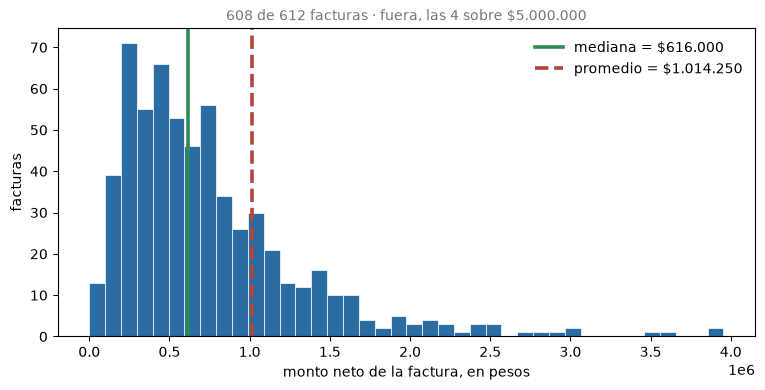

In [10]:
import matplotlib.pyplot as plt

media, mediana = facturas['monto_neto'].mean(), facturas['monto_neto'].median()

fig, ax = plt.subplots(figsize=(9, 4))
visibles = facturas.loc[facturas['monto_neto'] < 5e6, 'monto_neto']

ax.hist(visibles, bins=40, color='#2b6ca3', edgecolor='white', linewidth=0.5)
ax.axvline(mediana, color='#2e8b57', lw=2.6, label=f'mediana = ${mediana:,.0f}'.replace(',', '.'))
ax.axvline(media, color='#b5443a', lw=2.6, ls='--', label=f'promedio = ${media:,.0f}'.replace(',', '.'))
ax.set(xlabel='monto neto de la factura, en pesos', ylabel='facturas')
ax.legend(frameon=False)

# el promedio y la mediana se calculan sobre las 612; el dibujo recorta las de arriba de
# $5.000.000 para que la forma se vea. Un gráfico que filtra tiene que decir qué filtró
ax.set_title(f'{len(visibles)} de {len(facturas)} facturas · fuera, las 4 sobre $5.000.000',
             fontsize=10, color='#777')
plt.show()

La mitad de las facturas está bajo los **$616.000**, pero el promedio es **$1.014.250**: lo arrastra
una cola de facturas grandes.

Quien dimensione el trabajo de cobranza con el promedio está planificando para una factura que casi
no existe. El promedio no está mal calculado: **está mal usado como resumen** de una distribución
así.

In [11]:
# los dos montos se rotulan con el mismo replace del gráfico; por separado, para que el
# punto de miles no le llegue también a las comas de la frase
prom_pesos = f'${media:,.0f}'.replace(',', '.')
med_pesos = f'${mediana:,.0f}'.replace(',', '.')

anotar(
    variable='monto_neto',
    categoria='distribución',
    descripcion=f'Distribución muy asimétrica: el promedio queda {media / mediana - 1:.0%} por encima de la mediana.',
    evidencia=f'promedio {prom_pesos} vs mediana {med_pesos}, con cola larga a la derecha',
    severidad='media',
    impacto='Dimensionar la carga de cobranza con el promedio sobreestima la factura típica.',
)

,variable,categoría,descripción,evidencia,severidad,impacto
0,monto_neto,distribución,Distribución muy asimétrica: el promedio queda...,"promedio $1.014.250 vs mediana $616.000, con c...",media,Dimensionar la carga de cobranza con el promed...


---

# Parte 2 · Vamos juntos

Los pasos 3 y 4. El código está escrito: esto no es una clase de pandas. Lo que hacen ustedes es
**leer la salida, decidir si es hallazgo y redactar la línea**.

## Paso 3 · ¿Cómo se relacionan entre sí?

De a dos, y todas a la vez.

> **Antes de ejecutar:** de las cinco columnas numéricas, ¿cuáles esperan que se muevan juntas?

In [12]:
facturas.select_dtypes(include='number').corr().round(3)

,dias_credito,monto_neto,monto_total,monto_gestion_cobranza,dias_atraso
dias_credito,1.000,-0.024,-0.024,0.033,-0.005
monto_neto,-0.024,1.000,1.000,0.084,-0.001
monto_total,-0.024,1.000,1.000,0.084,-0.001
monto_gestion_cobranza,0.033,0.084,0.084,1.000,0.383
dias_atraso,-0.005,-0.001,-0.001,0.383,1.000


`monto_neto` y `monto_total` correlacionan **1,000**. No es una relación fuerte: es la **misma
medición dos veces**.

In [13]:
# round(2): a cuatro decimales asoman las facturas cargadas en miles, que son parte de la
# práctica de más abajo. Acá interesa la relación entre las dos columnas, no ese ruido
(facturas['monto_total'] / facturas['monto_neto']).round(2).value_counts()

1.19    612
Name: count, dtype: int64

La razón es siempre **1,19**. Es el **IVA**. Ninguna de las dos aporta información que la otra no
tenga.

Este hallazgo ya lo decidimos en clase, así que acá el paso 3 sirve para **reconocerlo**, no para
descubrirlo ni para volver a escribirlo. La primera línea que escriben ustedes viene en el paso 4.

## Paso 4 · ¿Qué se contradice?

Lo que debería cumplirse siempre y no se cumple. Tres miradas, tres técnicas.

### 4.1 · Contar: registros repetidos

> **Antes de ejecutar:** el archivo declara 612 facturas. ¿Son 612 facturas **distintas**?

In [14]:
copias = facturas.duplicated().sum()                     # solo las que sobran
repetidas = facturas[facturas.duplicated(keep=False)]    # keep=False: la original Y sus copias

print('Copias sobrantes    :', copias)
print('Registros involucrados:', len(repetidas))

Copias sobrantes    : 12
Registros involucrados: 24


> **Antes de ejecutar la celda siguiente:** esos registros repetidos, ¿de quién son? ¿Esperan que estén
> repartidas entre todos los ejecutivos?

In [15]:
repetidas['ejecutivo'].value_counts()

ejecutivo
M. Fuentes    24
Name: count, dtype: int64

**Las 24 son del mismo ejecutivo.**

Acá el hallazgo cambia de naturaleza. Doce registros repetidos es un error de datos; doce registros
repetidas **todas del mismo origen** es un hallazgo de **proceso**, y quien tiene que enterarse no
es el área de sistemas.

In [16]:
anotar(
    variable='(fila completa)',
    categoria='cantidad',
    descripcion=f'{copias} facturas duplicadas exactas, y los {len(repetidas)} registros involucrados son del mismo ejecutivo.',
    evidencia=f'duplicated().sum() = {copias}; value_counts() del ejecutivo devuelve un solo nombre',
    severidad='alta',
    impacto='Infla el monto de la cartera y la carga aparente de ese ejecutivo. Apunta a un problema '
            'de carga de datos, no solo a registros sobrantes.',
)

,variable,categoría,descripción,evidencia,severidad,impacto
0,(fila completa),cantidad,"12 facturas duplicadas exactas, y los 24 regis...",duplicated().sum() = 12; value_counts() del ej...,alta,Infla el monto de la cartera y la carga aparen...


### 4.2 · Agrupar y contar valores distintos: un cliente, dos nombres

Un RUT identifica a una empresa. Entonces cada RUT debería tener **una** razón social.

> **Antes de ejecutar:** ¿cuántos RUT creen que aparecen con más de un nombre?

`drop_duplicates` deja una sola fila por combinación repetida, que es lo que permite ver los
nombres distintos sin el ruido de cada factura.

In [17]:
nombres_por_rut = facturas.groupby('rut_cliente')['razon_social'].nunique()
inconsistentes = nombres_por_rut[nombres_por_rut > 1]

print('RUT con más de una razón social:', len(inconsistentes))
inconsistentes

RUT con más de una razón social: 5


rut_cliente
68.868.260-6    2
70.007.007-7    2
73.396.278-K    2
75.222.742-K    2
78.535.246-7    2
Name: razon_social, dtype: int64

In [18]:
# cómo se ven los nombres de uno de ellos
rut = inconsistentes.index[0]
facturas.loc[facturas['rut_cliente'] == rut, ['rut_cliente', 'razon_social']].drop_duplicates()

,rut_cliente,razon_social
28,68.868.260-6,Comercial Andes
143,68.868.260-6,Comercial Andes S.A.


> **Su turno, en voz alta y sin escribir nada todavía:** ¿por qué esto importa para la decisión que
> se va a apoyar? Piensen qué pasa si alguien agrupa por `razon_social` en vez de por
> `rut_cliente`. Guárdense el argumento: el campo **impacto** de la línea que van a escribir en la
> celda siguiente se redacta exactamente así.

### 4.3 · Comparar dos columnas: lo que es imposible

Una factura no puede pagarse antes de emitirse. Eso no es una regla de negocio discutible: es una
imposibilidad lógica.

Las fechas llegan como texto, así que antes de restarlas hay que convertirlas con
`to_datetime`.

In [19]:
emision = pd.to_datetime(facturas['fecha_emision'])
pago = pd.to_datetime(facturas['fecha_pago'], errors='coerce')

imposibles = facturas[pago < emision]

print('Facturas pagadas antes de emitirse:', len(imposibles))
imposibles[['id_factura', 'fecha_emision', 'fecha_pago', 'dias_atraso']]

Facturas pagadas antes de emitirse: 5


,id_factura,fecha_emision,fecha_pago,dias_atraso
31,F-0211,2025-02-03,2025-01-28,0
308,F-0334,2025-08-06,2025-07-31,13
372,F-0097,2025-08-21,2025-08-15,13
464,F-0013,2025-06-05,2025-05-30,10
544,F-0456,2025-02-18,2025-02-12,13


Cinco facturas. Ninguna herramienta las marcó: las dos fechas son fechas válidas, y **la
contradicción solo aparece al compararlas entre sí**.

> **Su turno:** anoten este hallazgo. Presten atención al campo de severidad — acá hay una
> inconsistencia lógica **verificada**, no una sospecha.

In [20]:
# descomenten y completen
# anotar(
#     variable='fecha_pago / fecha_emision',
#     categoria='...',
#     descripcion='...',   # completar
#     evidencia='...',     # completar
#     severidad='...',     # completar
#     impacto='...',       # completar
# )

---

# Parte 3 · Ahora ustedes

El paso 5, por cuenta propia.

## Paso 5 · ¿De qué momento es cada dato?

**Fuga de datos** (*data leakage*): información en las variables predictoras que **no va a estar
disponible en el momento de decidir**, o que ya contiene la respuesta.

En este archivo hay tres sospechosas, una por cada señal. Las tres celdas de abajo revelan una cada
una.

**Obligatorio: elijan UNA**, ejecútenla, lean la salida y escriban su línea de bitácora. Lo que se
evalúa no es el código —está escrito— sino el argumento: **por qué** esa columna es sospechosa y
**qué le preguntarían al dueño del dato**.

**Señal A · Es la respuesta con otras palabras.** Separa el objetivo sin equivocarse nunca.

In [21]:
pd.crosstab(facturas['estado_cobranza'], facturas['dias_atraso'] > 0)

dias_atraso,False,True
estado_cobranza,,
en gestión judicial,0,25
pagada al día,201,0
pagada con atraso,0,386


**Señal B · Solo existe si el evento ocurrió.** Vale cero en todos los demás casos.

In [22]:
facturas.groupby(facturas['dias_atraso'] > 0)['monto_gestion_cobranza'].describe()

,count,mean,std,min,25%,50%,75%,max
dias_atraso,,,,,,,,
False,201.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
True,411.0,16195.766423,14077.407625,1340.0,7350.0,13120.0,20990.0,117440.0


**Señal C · Es una cifra del período.** No varía dentro del mes.

In [23]:
mes = facturas['fecha_emision'].str[:7]
facturas.groupby(mes)['tasa_morosidad_cartera'].nunique()

fecha_emision
2025-01    1
2025-02    1
2025-03    1
2025-04    1
2025-05    1
2025-06    1
2025-07    1
2025-08    1
2025-09    1
2025-10    1
2025-11    1
2025-12    1
Name: tasa_morosidad_cartera, dtype: int64

> **Ojo con la versión fácil.** «La variable con fuga está vacía hasta que ocurre el evento» no
> sirve: la tasa de morosidad está en **todos** los registros y es sospechosa igual. Lo que llega tarde
> no es el dato: es su **valor**.

Y la respuesta **no está en el archivo**: la tiene quien es dueño del dato. De acá se sale con una
**lista de sospechosos**, no con un dictamen.

In [24]:
# su hallazgo obligatorio: una señal de fuga, sustentada · descomenten y completen
# anotar(
#     variable='...',
#     categoria='...',
#     descripcion='...',
#     evidencia='...',
#     severidad='...',
#     impacto='...',
# )

## Un hallazgo a elección

Elijan **uno** de los tres y agréguenlo a la bitácora. Las celdas de abajo son puntos de partida:
tendrán que completarlas.

1. Los **8 montos** que están cargados en miles y no en pesos.
2. El **contrato de $148 millones**: ¿error o caso real? Argumenten.
3. La columna que **ningún estadístico está mirando**, y qué se pierde por eso.

> Sobre la tercera: la celda convierte la columna para **dimensionar lo que se está perdiendo**, no
> para arreglar el archivo. Corregirlo de verdad es la clase 4.

`to_numeric` intenta convertir a número, y con `errors='coerce'` deja vacío lo que no puede
convertir en vez de detenerse con un error.

In [25]:
# opción 1 · los montos en otra unidad
facturas.nsmallest(12, 'monto_neto')[['id_factura', 'razon_social', 'segmento', 'monto_neto']]

,id_factura,razon_social,segmento,monto_neto
324,F-0403,Comercial del Sur,corporativo,156
322,F-0342,Servicios Aconcagua,corporativo,293
219,F-0032,Comercial Central,pyme,383
95,F-0146,Servicios Aconcagua,corporativo,392
153,F-0089,Ingeniería Andes,pyme,561
470,F-0478,Servicios Cordillera,pyme,616
57,F-0269,Ingeniería Aconcagua,corporativo,827
226,F-0204,Comercial Central,pyme,2792
218,F-0396,Constructora Andes,pyme,67000
156,F-0394,Transportes Cordillera,pyme,74000


In [26]:
# opción 2 · la factura más grande de la cartera
facturas.nlargest(3, 'monto_neto')[['id_factura', 'razon_social', 'segmento', 'monto_neto', 'dias_credito']]

,id_factura,razon_social,segmento,monto_neto,dias_credito
229,F-0008,Constructora Cordillera,gobierno,148000000,30
372,F-0097,Distribuidora Araucanía,pyme,5872000,90
100,F-0534,Servicios Cordillera,gobierno,5627000,60


In [27]:
# opción 3 · qué pasaría si esa columna SÍ fuera número
convertida = pd.to_numeric(facturas['tasa_morosidad_cartera'].str.replace(',', '.'), errors='coerce')
convertida.describe()

count    612.000000
mean       5.005229
std        1.293141
min        2.700000
25%        3.900000
50%        5.700000
75%        6.100000
max        6.600000
Name: tasa_morosidad_cartera, dtype: float64

In [28]:
# su hallazgo a elección · descomenten y completen
# anotar(
#     variable='...',
#     categoria='...',
#     descripcion='...',
#     evidencia='...',
#     severidad='...',
#     impacto='...',
# )

---

## La bitácora

Lo que queda al terminar. No es un archivo corregido: es la lista de lo que se encontró, con qué lo
demuestra y a qué decisión afecta.

In [29]:
bitacora = pd.DataFrame(BITACORA)

print(f'{len(bitacora)} hallazgos registrados')
bitacora

3 hallazgos registrados


,variable,categoría,descripción,evidencia,severidad,impacto
0,tasa_morosidad_cartera,formato,Llega con coma decimal y pandas la lee como te...,describe() devuelve 5 columnas; select_dtypes(...,alta,Queda fuera de todo cálculo sin que nada avise...
1,monto_neto,distribución,Distribución muy asimétrica: el promedio queda...,"promedio $1.014.250 vs mediana $616.000, con c...",media,Dimensionar la carga de cobranza con el promed...
2,(fila completa),cantidad,"12 facturas duplicadas exactas, y los 24 regis...",duplicated().sum() = 12; value_counts() del ej...,alta,Infla el monto de la cartera y la carga aparen...


## Para cerrar

La rutina, en orden, y lo que cazó cada paso en este archivo:

| Paso | Qué se preguntó | Qué apareció |
|:--|:--|:--|
| 1 | ¿Qué es cada columna? | Un porcentaje que llegó como texto |
| 2 | ¿Cómo se comporta cada una? | Un promedio que describe una factura que casi no existe |
| 3 | ¿Cómo se relacionan? | Dos columnas que son la misma con IVA |
| 4 | ¿Qué se contradice? | Duplicados de un solo ejecutivo, RUT con dos nombres, pagos imposibles |
| 5 | ¿De qué momento es cada dato? | Tres columnas cuyo valor llega después de decidir |

El archivo declaraba **cero celdas vacías**. Ninguno de estos hallazgos aparece en `info()`.

**Nada de esto se corrigió hoy.** Decidir qué hacer con cada hallazgo —imputar, eliminar,
transformar, o preguntarle a quien es dueño del dato— es la clase 4. Lo que se lleva de acá es la
bitácora, y la rutina de cinco pasos, que sirve para cualquier archivo que les pongan por delante.

## Atribución de datos

- **Creador:** Sebastián Contreras, para este curso.
- **Procedencia:** dato **sintético**, generado por [`_prep_cobranza_servicios.py`](../datasets/_prep_cobranza_servicios.py).
  El script es determinista y de semilla fija. **No representa a ninguna organización real**: los RUT
  son inventados, con dígito verificador válido solo para que el formato resulte reconocible.
- **Licencia:** No declarada.
- **Modificación:** no aplica. El archivo se genera completo desde ese script y no deriva de una obra
  de terceros.